# SKEMPI 2.0 — antibody/antigen EDA

Scope: the **AB/AG subset only**. Purpose is to understand the entities we are modelling, the
shape of the label, and the data hazards that decide how many rows actually survive to training.

This notebook is descriptive and exploratory. Nothing here writes a frozen artefact — the
committed `folds.csv` is produced later by `src/splits.py`. The last section only checks whether
a balanced clustered split is *feasible*.

Dependencies: `pandas`, `numpy`, `matplotlib`, `scipy`. PDB parsing is stdlib, no biopython.

## 1. Setup

In [1]:
from pathlib import Path
import re, tarfile, itertools, difflib, collections
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

# --- locate repo root (works from notebooks/ or repo root) ---
ROOT = Path.cwd()
while not (ROOT / "data" / "skempi_v2.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "data"
assert (DATA / "skempi_v2.csv").exists(), f"skempi_v2.csv not found from {Path.cwd()}"
print("repo root:", ROOT)

# --- unpack structures once ---
PDB_DIR = DATA / "PDBs"
if not PDB_DIR.exists():
    tgz = DATA / "SKEMPI2_PDBs.tgz"
    print("unpacking", tgz.name)
    with tarfile.open(tgz) as t:
        t.extractall(DATA)
print("PDB files:", len(list(PDB_DIR.glob("*.pdb"))))

R_GAS = 0.0019872041   # kcal / (mol K)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

repo root: /home/claude/work
PDB files: 690


In [2]:
# --- plotting style: fixed categorical order, diverging pair for signed values ---
C = {"blue":"#2a78d6","orange":"#eb6834","aqua":"#1baf7a","yellow":"#eda100",
     "magenta":"#e87ba4","green":"#008300","violet":"#4a3aa7","red":"#e34948"}
SEQ = ["#cde2fb","#9ec5f4","#6da7ec","#3987e5","#2a78d6","#256abf","#184f95","#0d366b"]
INK, INK2, MUTED, GRIDC, BASEC, SURF = "#0b0b0b","#52514e","#898781","#e1e0d9","#c3c2b7","#fcfcfb"
NEG, MID, POS = C["blue"], "#f0efec", C["red"]   # diverging: stabilising <-> destabilising

plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "font.family": "sans-serif", "font.size": 10,
    "axes.edgecolor": BASEC, "axes.linewidth": 1.0, "axes.labelcolor": INK2,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": GRIDC, "grid.linewidth": 0.8, "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 110,
})

def style(ax, title=None, xlabel=None, ylabel=None, grid="y"):
    if title:  ax.set_title(title, loc="left", pad=10)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    for s in ("top","right"): ax.spines[s].set_visible(False)
    if grid: ax.grid(axis=grid, alpha=.9, zorder=0); ax.set_axisbelow(True)
    return ax

## 2. Load, build the label, and log every dropped row

`ddG = R T ln(Kd_mut / Kd_wt)`, kcal/mol, **positive = mutation weakens binding**. Temperature is
parsed from the `Temperature` column; SKEMPI marks a large share of these as "assumed", which we
flag rather than silently trust.

In [3]:
raw = pd.read_csv(DATA / "skempi_v2.csv", sep=";")
ab  = raw[raw["Hold_out_type"].fillna("").str.contains("AB/AG")].copy()

drops = [("AB/AG rows in SKEMPI 2.0", len(ab), "")]

# temperature
tnum = ab["Temperature"].astype(str).str.extract(r"(\d+)")[0].astype(float)
ab["temp_assumed"] = ab["Temperature"].astype(str).str.contains("assumed", case=False)
ab["T"] = tnum.fillna(298.0)

# inequality / non-binder flags, kept before dropping so we can count them
for side in ("mut","wt"):
    ab[f"{side}_is_bound"] = ab[f"Affinity_{side} (M)"].astype(str).str.contains(r"[<>]", regex=True)

ab["ddG"] = R_GAS * ab["T"] * np.log(ab["Affinity_mut_parsed"] / ab["Affinity_wt_parsed"])

n0, c0 = len(ab), ab["#Pdb"].nunique()
ab = ab[np.isfinite(ab["ddG"])].copy()
drops.append(("after dropping rows with no parsable mutant/wt affinity", len(ab), f"-{n0-len(ab)}"))
print(f"complexes before/after this drop: {c0} -> {ab['#Pdb'].nunique()}"
      f"   ({c0-ab['#Pdb'].nunique()} complex lost entirely)")

ab["n_mut"] = ab["Mutation(s)_cleaned"].str.count(",") + 1
ab["pdb"]   = ab["#Pdb"].str.split("_").str[0]
ab["side1"] = ab["#Pdb"].str.split("_").str[1]
ab["side2"] = ab["#Pdb"].str.split("_").str[2]

drop_tbl = pd.DataFrame(drops, columns=["step","rows remaining","delta"])
drop_tbl

complexes before/after this drop: 55 -> 54   (1 complex lost entirely)


,step,rows remaining,delta
0,AB/AG rows in SKEMPI 2.0,1211,
1,after dropping rows with no parsable mutant/wt...,1131,-80


In [4]:
# duplicate (complex, mutation) measurements: keep them for now, they are our noise estimate
dup_key = ["#Pdb","Mutation(s)_cleaned"]
g = ab.groupby(dup_key)["ddG"]
dup_stats = g.agg(n="size", mean="mean", sd="std", ptp=lambda s: s.max()-s.min())
print(f"unique (complex, mutation) pairs : {len(dup_stats):,}")
print(f"pairs measured more than once    : {(dup_stats['n']>1).sum():,}"
      f"  covering {dup_stats.loc[dup_stats['n']>1,'n'].sum():,} rows")
dup_stats[dup_stats.n>1].sort_values("ptp", ascending=False).head(8)

unique (complex, mutation) pairs : 997
pairs measured more than once    : 122  covering 256 rows


n      mean        sd       ptp
#Pdb       Mutation(s)_cleaned                                            
4I77_HL_Z  YL32A                           2  0.815066  1.152677  1.630132
           YH101A                          2  1.653839  1.007931  1.425430
1JRH_LH_I  RI74A                           2  0.392617  0.903582  1.277858
1CZ8_HL_VW LL4M,DH28T,HH31N,YH101H,TH105S  2  2.367331  0.809662  1.145035
1MLC_AB_E  NA92A,TB28D,SB57V,TB58D         3 -2.328930  0.579468  1.073295
4I77_HL_Z  YH103A                          2  2.197438  0.715414  1.011748
           DH54A                           2  2.619286  0.700785  0.991060
1JRH_LH_I  NI38A                           2  0.170458  0.655408  0.926887

## 3. Entity inventory

What distinct things exist in this subset, and at what granularity does leakage happen? The unit
of measurement is a *mutation*, but the unit of *independence* is much coarser — a complex, or a
cluster of related complexes.

In [5]:
# Protein 1 <-> side1 chains, Protein 2 <-> side2 chains (verified against known cases, e.g.
# 3HFM_HL_Y: Protein 1 = HyHEL-10 antibody = chains HL; Protein 2 = HEW Lysozyme = chain Y)
AB_NAME = re.compile(r"\b(?:fab|fv|scfv|antibody|igg|ig[ag]|mab|monoclonal|hyhel|nanobody|vhh)\b", re.I)

cx = ab.drop_duplicates("#Pdb")[["#Pdb","pdb","side1","side2","Protein 1","Protein 2"]].copy()
cx["p1_is_ab"] = cx["Protein 1"].fillna("").str.contains(AB_NAME)
cx["p2_is_ab"] = cx["Protein 2"].fillna("").str.contains(AB_NAME)

def ab_side(r):
    if r.p1_is_ab and not r.p2_is_ab: return 1
    if r.p2_is_ab and not r.p1_is_ab: return 2
    return 0                      # ambiguous: both look like antibodies, or neither does
cx["ab_side"] = cx.apply(ab_side, axis=1)
cx["ab_chains"]  = np.where(cx.ab_side==1, cx.side1, np.where(cx.ab_side==2, cx.side2, ""))
cx["ag_chains"]  = np.where(cx.ab_side==1, cx.side2, np.where(cx.ab_side==2, cx.side1, ""))

print("antibody side resolved by protein name:")
print(cx.ab_side.map({1:"Protein 1",2:"Protein 2",0:"AMBIGUOUS"}).value_counts().to_string())
print()
print("ambiguous complexes (checked against structure in section 7):")
print(cx.loc[cx.ab_side==0, ["#Pdb","Protein 1","Protein 2"]].to_string(index=False))

antibody side resolved by protein name:
ab_side
Protein 1    36
Protein 2    13
AMBIGUOUS     5

ambiguous complexes (checked against structure in section 7):
      #Pdb          Protein 1                 Protein 2
1DVF_AB_CD IgG1-kappa D1.3 Fv                   E5.2 Fv
 1JRH_LH_I            mAbs A6 Interferon gamma receptor
 1N8Z_AB_C          Herceptin                    erbB-2
 3N85_A_LH               HER2                     Fab37
 3SE9_HL_G           VRC-PG04                     gp120


In [6]:
inventory = pd.DataFrame([
    ("measurements (rows)",            len(ab)),
    ("unique (complex, mutation)",     ab.groupby(dup_key).ngroups),
    ("complexes (#Pdb)",               ab["#Pdb"].nunique()),
    ("PDB structures",                 ab["pdb"].nunique()),
    ("distinct chains across subset",  len({(p,c) for p,s1,s2 in zip(ab.pdb,ab.side1,ab.side2) for c in s1+s2})),
    ("distinct Protein 1 names",       ab["Protein 1"].nunique()),
    ("distinct Protein 2 names",       ab["Protein 2"].nunique()),
    ("source publications",            ab["Reference"].nunique()),
    ("assay methods",                  ab["Method"].nunique()),
], columns=["entity","count"]).set_index("entity")
inventory

,count
entity,
measurements (rows),1131
"unique (complex, mutation)",997
complexes (#Pdb),54
PDB structures,54
distinct chains across subset,173
distinct Protein 1 names,34
distinct Protein 2 names,31
source publications,50
assay methods,10


count     54.0
mean      20.9
std       25.6
min        1.0
25%        4.0
50%       10.5
75%       27.8
max      112.0

top 3 complexes hold 26.3% of rows: 3HFM_HL_Y, 1MHP_HL_A, 2B2X_HL_A
top 10 hold 57.6%
complexes with < 5 rows: 19 of 54  (holding 52 rows)


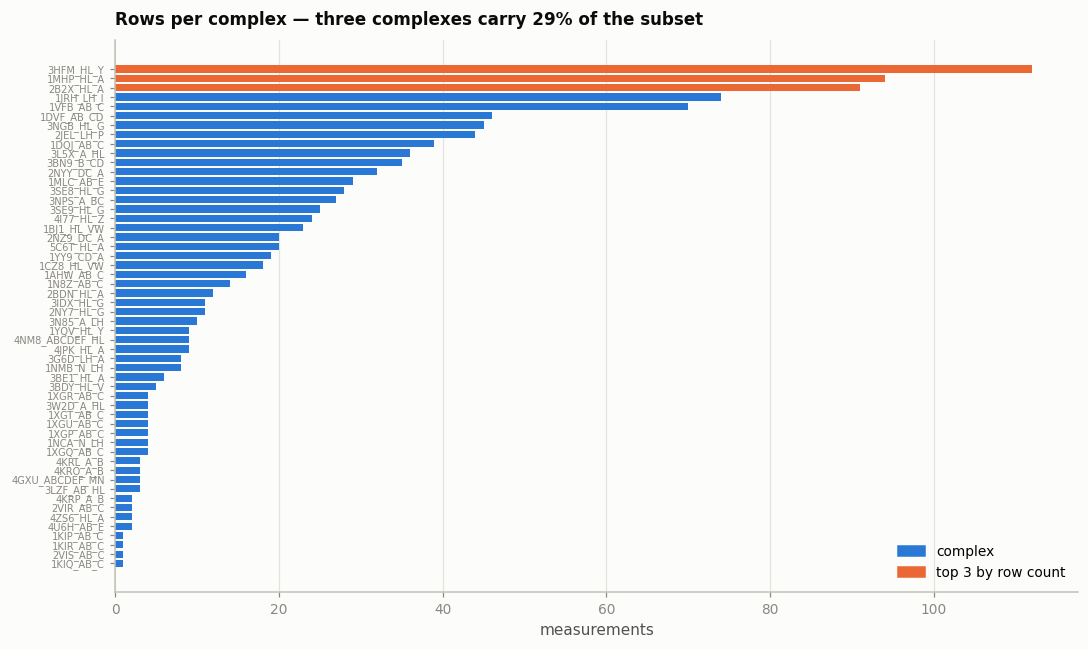

In [7]:
rows_per_cx = ab["#Pdb"].value_counts()
top3 = rows_per_cx.head(3)
print(rows_per_cx.describe().round(1).to_string())
print(f"\ntop 3 complexes hold {top3.sum()/len(ab):.1%} of rows: {', '.join(top3.index)}")
print(f"top 10 hold {rows_per_cx.head(10).sum()/len(ab):.1%}")
print(f"complexes with < 5 rows: {(rows_per_cx<5).sum()} of {len(rows_per_cx)}"
      f"  (holding {rows_per_cx[rows_per_cx<5].sum()} rows)")

fig, ax = plt.subplots(figsize=(10,6))
v = rows_per_cx.sort_values()
cols = [C["orange"] if x in top3.index else C["blue"] for x in v.index]
ax.barh(range(len(v)), v.values, color=cols, height=.78)
ax.set_yticks(range(len(v))); ax.set_yticklabels(v.index, fontsize=6.5)
ax.legend(handles=[Patch(color=C["blue"], label="complex"),
                   Patch(color=C["orange"], label="top 3 by row count")], loc="lower right")
style(ax, "Rows per complex — three complexes carry 29% of the subset", "measurements", grid="x")
plt.tight_layout(); plt.show()

In [8]:
# how many rows sit on the antibody side vs the antigen side?
chain_of = lambda m: [x[1] for x in re.findall(r"([A-Z])([A-Za-z])(\d+)([A-Z])", m)]

def compute_mut_side(frame, cx_tbl):
    smap = cx_tbl.set_index("#Pdb")[["ab_chains","ag_chains"]].to_dict("index")
    def one(row):
        d  = smap[row["#Pdb"]]
        ch = set(chain_of(row["Mutation(s)_cleaned"]))
        on_ab = bool(ch & set(d["ab_chains"])); on_ag = bool(ch & set(d["ag_chains"]))
        if on_ab and on_ag: return "both sides"
        if on_ab: return "antibody"
        if on_ag: return "antigen"
        return "unresolved"
    return frame.apply(one, axis=1)

ab["mut_side"] = compute_mut_side(ab, cx)
print("from protein names alone:")
print(ab["mut_side"].value_counts().to_string())
print("\n'unresolved' are the ambiguous complexes above — section 7 resolves them from structure.")

from protein names alone:
mut_side
antibody      579
antigen       340
unresolved    169
both sides     43

'unresolved' are the ambiguous complexes above — section 7 resolves them from structure.


## 4. Label distribution

The two things that matter for evaluation design: the label is strongly skewed toward
destabilising, and the **within-complex** spread is much tighter than the global spread. The
second point is why a global correlation flatters a model that has only learned which complex it
is looking at.

count    1131.00
mean        1.06
std         1.80
min        -4.91
25%         0.00
50%         0.75
75%         1.87
max         7.94

stabilising  (ddG < -0.5) :  12.6%
neutral-ish  (|ddG| <= 0.5):  31.4%
destabilising (ddG > 0.5) :  56.1%
exactly zero               : 57 rows


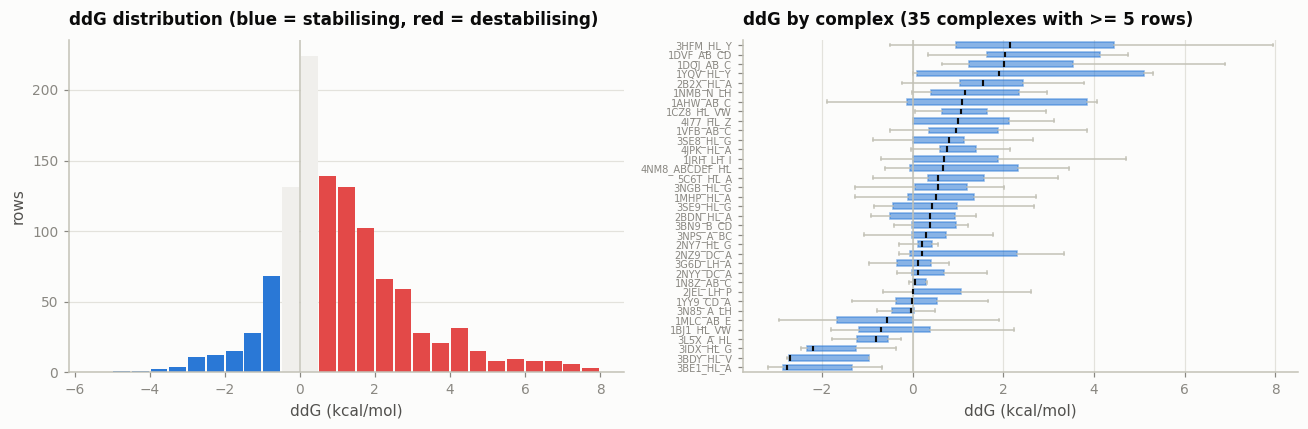

In [9]:
d = ab["ddG"]
print(d.describe().round(2).to_string())
print(f"\nstabilising  (ddG < -0.5) : {(d<-0.5).mean():6.1%}")
print(f"neutral-ish  (|ddG| <= 0.5): {(d.abs()<=0.5).mean():6.1%}")
print(f"destabilising (ddG > 0.5) : {(d>0.5).mean():6.1%}")
print(f"exactly zero               : {(d==0).sum()} rows")

fig, axes = plt.subplots(1,2, figsize=(12,4))
ax = axes[0]
bins = np.arange(-5.5, 8.5, .5)
cnt, edges = np.histogram(d, bins=bins)
centres = (edges[:-1]+edges[1:])/2
cols = [NEG if c < -0.25 else (POS if c > 0.25 else MID) for c in centres]
ax.bar(centres, cnt, width=.45, color=cols)
ax.axvline(0, color=BASEC, lw=1)
style(ax, "ddG distribution (blue = stabilising, red = destabilising)", "ddG (kcal/mol)", "rows")

ax = axes[1]
sub = rows_per_cx[rows_per_cx>=5].index
order = ab[ab["#Pdb"].isin(sub)].groupby("#Pdb")["ddG"].median().sort_values().index
bp = ax.boxplot([ab.loc[ab["#Pdb"]==k,"ddG"].values for k in order], vert=False,
                widths=.6, patch_artist=True, showfliers=False)
for p in bp["boxes"]:    p.set(facecolor=C["blue"], alpha=.55, edgecolor=C["blue"], lw=1)
for k in ("whiskers","caps"):
    for p in bp[k]: p.set(color=BASEC, lw=1)
for p in bp["medians"]:  p.set(color=INK, lw=1.4)
ax.set_yticklabels(order, fontsize=6.5); ax.axvline(0, color=BASEC, lw=1)
style(ax, f"ddG by complex ({len(order)} complexes with >= 5 rows)", "ddG (kcal/mol)", grid="x")
plt.tight_layout(); plt.show()

In [10]:
# global vs within-complex spread, and what that implies for the achievable correlation
w = ab.groupby("#Pdb")["ddG"].agg(["count","std"])
w = w[w["count"]>=5]
sd_global   = ab["ddG"].std()
sd_within   = w["std"].median()

# two independent estimates of measurement noise
dups = dup_stats[dup_stats.n>1]
sd_noise_emp = np.sqrt(np.nanmean(dups["sd"]**2))          # pooled within-pair SD, this subset
sd_noise_pap = 1.0 / (stats.norm.ppf(0.92) * np.sqrt(2))   # paper: 84% of repeats within 1 kcal/mol

def ceiling(sd_signal, sd_noise):
    rel = max(0.0, sd_signal**2 - sd_noise**2) / sd_signal**2
    return rel, np.sqrt(rel)

rows=[]
for nname, sn in [("empirical (duplicate pairs)", sd_noise_emp), ("paper (84% within 1 kcal/mol)", sd_noise_pap)]:
    for sname, ss in [("global", sd_global), ("median within-complex", sd_within)]:
        rel, r = ceiling(ss, sn)
        rows.append((nname, round(sn,2), sname, round(ss,2), round(rel,3), round(r,3)))
ceil_tbl = pd.DataFrame(rows, columns=["noise estimate","noise SD","signal scope","signal SD",
                                       "reliability","max attainable r"])
print(f"duplicate pairs used for the empirical estimate: {len(dups)}")
print(f"repeated pairs agreeing within 1 kcal/mol here: {(dups['ptp']<=1).mean():.1%}"
      f"  (paper reports 84% across all of SKEMPI)")
print()
print("CAUTION: our duplicate pairs are often the same mutation re-reported by the same group,")
print("so the empirical estimate is optimistic. The paper's figure comes from measurements by")
print("independent groups. Report the paper-derived ceiling as the conservative one.")
ceil_tbl

duplicate pairs used for the empirical estimate: 122
repeated pairs agreeing within 1 kcal/mol here: 95.1%  (paper reports 84% across all of SKEMPI)

CAUTION: our duplicate pairs are often the same mutation re-reported by the same group,
so the empirical estimate is optimistic. The paper's figure comes from measurements by
independent groups. Report the paper-derived ceiling as the conservative one.


,noise estimate,noise SD,signal scope,signal SD,reliability,max attainable r
0,empirical (duplicate pairs),0.31,global,1.80,0.970,0.985
1,empirical (duplicate pairs),0.31,median within-complex,1.19,0.932,0.966
2,paper (84% within 1 kcal/mol),0.50,global,1.80,0.922,0.960
3,paper (84% within 1 kcal/mol),0.50,median within-complex,1.19,0.822,0.906


## 5. Mutation distribution

The single biggest compositional fact in this subset is that it is mostly an alanine scan.

In [ ]:
print(ab["n_mut"].value_counts().sort_index().to_string())
sing = ab[ab.n_mut==1].copy()
sing["wt_aa"]  = sing["Mutation(s)_cleaned"].str[0]
sing["mut_aa"] = sing["Mutation(s)_cleaned"].str[-1]
print(f"\nsingle-point rows: {len(sing)}  ({len(sing)/len(ab):.1%})")
print(f"  of which X->Ala : {(sing.mut_aa=='A').sum()}  ({(sing.mut_aa=='A').mean():.1%})")
print()
print(sing.groupby(sing.mut_aa=='A')["ddG"].agg(["size","mean","std"]).round(2)
        .rename(index={True:"X->Ala", False:"other"}).to_string())


n_mut
1     797
2     109
3      57
4      53
5      67
6      20
7       8
8      10
9       2
11      1
12      2
13      3
14      2

single-point rows: 797  (70.5%)
  of which X->Ala : 426  (53.5%)

        size  mean   std
mut_aa                  
other    371  0.86  1.55
X->Ala   426  1.28  1.63


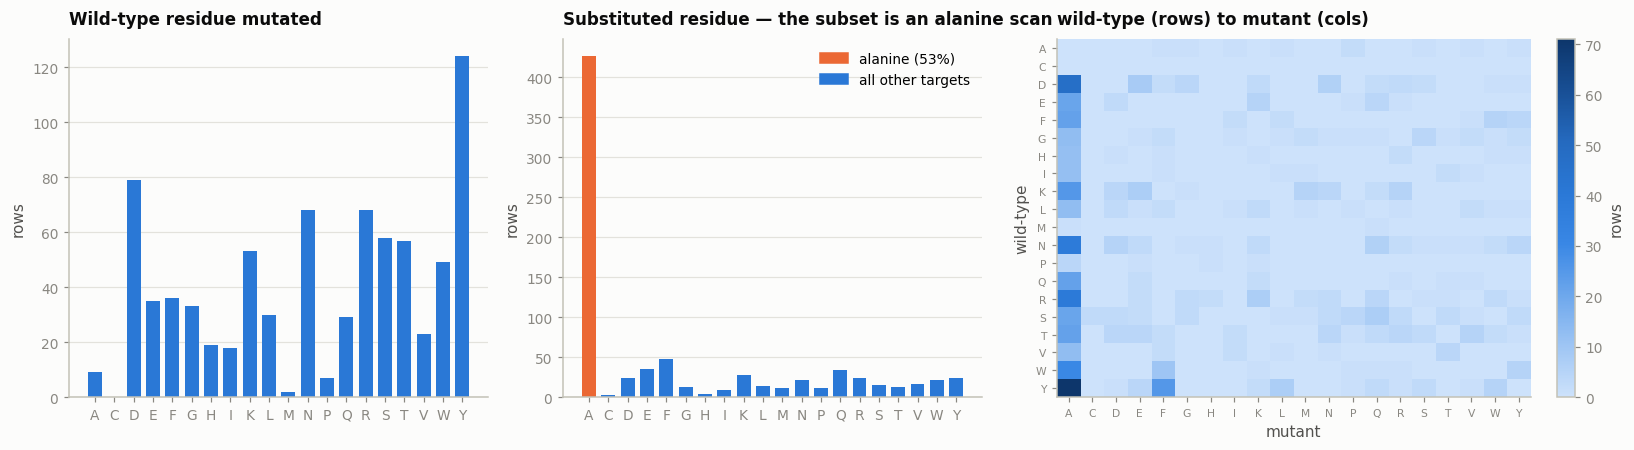

In [12]:
AAS = list("ACDEFGHIKLMNPQRSTVWY")
fig, axes = plt.subplots(1,3, figsize=(15,4.2), gridspec_kw={"width_ratios":[1,1,1.25]})

ax = axes[0]
v = sing.wt_aa.value_counts().reindex(AAS).fillna(0)
ax.bar(v.index, v.values, color=C["blue"], width=.72)
style(ax, "Wild-type residue mutated", None, "rows")

ax = axes[1]
v = sing.mut_aa.value_counts().reindex(AAS).fillna(0)
cols = [C["orange"] if a=="A" else C["blue"] for a in AAS]
ax.bar(v.index, v.values, color=cols, width=.72)
ax.legend(handles=[Patch(color=C["orange"], label="alanine (53%)"),
                   Patch(color=C["blue"], label="all other targets")], loc="upper right")
style(ax, "Substituted residue — the subset is an alanine scan", None, "rows")

ax = axes[2]
M = pd.crosstab(sing.wt_aa, sing.mut_aa).reindex(index=AAS, columns=AAS).fillna(0)
cmap = LinearSegmentedColormap.from_list("seq", SEQ)
im = ax.imshow(M.values, cmap=cmap, aspect="auto")
ax.set_xticks(range(20)); ax.set_xticklabels(AAS, fontsize=7)
ax.set_yticks(range(20)); ax.set_yticklabels(AAS, fontsize=7)
plt.colorbar(im, ax=ax, label="rows", fraction=.046)
style(ax, "wild-type (rows) to mutant (cols)", "mutant", "wild-type", grid=None)
plt.tight_layout(); plt.show()

In [13]:
# interface location categories, as curated by SKEMPI
loc = ab.loc[ab.n_mut==1, "iMutation_Location(s)"].value_counts()
print("single-point mutations by interface location:")
print(loc.to_string())
lt = ab[ab.n_mut==1].groupby("iMutation_Location(s)")["ddG"].agg(["size","mean","std"]).round(2)
lt = lt[lt["size"]>=10].sort_values("mean", ascending=False)
print()
print("COR=interface core, SUP=support, RIM=rim, SUR=surface, INT=interior")
lt

single-point mutations by interface location:
iMutation_Location(s)
COR    352
RIM    184
SUP    134
SUR     91
INT     36

COR=interface core, SUP=support, RIM=rim, SUR=surface, INT=interior


,size,mean,std
iMutation_Location(s),,,
COR,352,1.61,1.67
SUP,134,1.38,1.98
INT,36,0.74,1.39
RIM,184,0.42,0.99
SUR,91,0.08,0.36


## 6. Data hazards

Each of these was flagged either by the SKEMPI 2.0 paper or by the curators' own `Notes` column.
They matter because they change what a row *means*, not just how noisy it is.

In [14]:
notes = ab["Notes"].fillna("")
nonnative = notes.str.contains(r"affinity matured|taken as ['\"]?wild.?type|is one of the mutants", case=False)
similar   = notes.str.contains(r"very similar", case=False)

hz = pd.DataFrame([
    ("temperature marked 'assumed'",        int(ab.temp_assumed.sum()),
     "ddG scale is approximate for these rows"),
    ("mutant affinity given as a bound",     int(ab.mut_is_bound.sum()),
     "censored, not a point measurement"),
    ("wild-type affinity given as a bound",  int(ab.wt_is_bound.sum()), "censored reference"),
    ("non-native reference state",           int(nonnative.sum()),
     "'wild-type' is an affinity-matured Fab or another mutant"),
    ("curator flags near-identical partner", int(similar.sum()),
     "explicit homology warning -> must not straddle folds"),
    ("duplicate (complex, mutation) rows",   int(dup_stats.loc[dup_stats.n>1,'n'].sum()),
     "aggregate before training; spread estimates label noise"),
], columns=["hazard","rows","why it matters"]).set_index("hazard")
hz["% of subset"] = (hz["rows"]/len(ab)*100).round(1)
hz[["rows","% of subset","why it matters"]]

,rows,% of subset,why it matters
hazard,,,
temperature marked 'assumed',540,47.7,ddG scale is approximate for these rows
mutant affinity given as a bound,45,4.0,"censored, not a point measurement"
wild-type affinity given as a bound,41,3.6,censored reference
non-native reference state,167,14.8,'wild-type' is an affinity-matured Fab or anot...
curator flags near-identical partner,151,13.4,explicit homology warning -> must not straddle...
"duplicate (complex, mutation) rows",256,22.6,aggregate before training; spread estimates la...


In [15]:
print("curator notes appearing on 10+ rows:")
print(notes[notes!=""].value_counts().head(8).to_string())
print()
print("ddG on non-native-reference rows vs the rest:")
print(ab.groupby(nonnative)["ddG"].agg(["size","mean","std"]).round(2)
        .rename(index={True:"non-native reference", False:"native wild-type"}).to_string())

curator notes appearing on 10+ rows:
Notes
NB) HyHEL-10 and HyHEL-63 are very similar,,                                                                                                                             145
Crystal structure is the affinity matured fab reported in the paper. This is taken as 'wild-type'                                                                         89
Unusual method,,                                                                                                                                                          44
'wild-type' is affinity matured AR2                                                                                                                                       31
Crystal structure is one of the mutants in the paper. This mutant is taken as 'wild-type' and is mutated to another mutant.                                               20
Five mutations in the CDR-L1 regions are not included, as these solvent exposed residues and

        size  mean   std
Method                  
SPR      533  0.85  1.69
ELISA    156  1.48  1.23
FL       115  0.33  1.59
KinExA    98  0.64  1.37
IASP      78  1.83  1.82
CSPRIA    44  0.90  1.63
SP        44  4.00  2.57
ITC       44  0.79  2.15


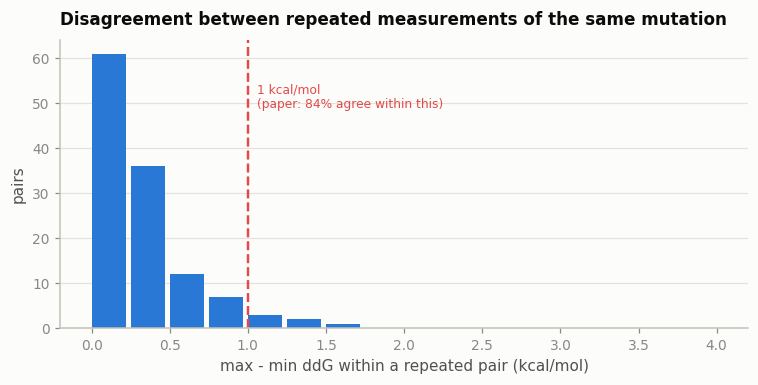


repeated pairs agreeing within 1 kcal/mol: 95.1%  (n=122)


In [16]:
# assay method: a proxy for label noise. Does the spread differ by method?
m = ab.groupby("Method")["ddG"].agg(["size","mean","std"]).round(2).sort_values("size", ascending=False)
m = m[m["size"]>=20]
print(m.to_string())

dd = dups.reset_index().merge(ab[["#Pdb","Mutation(s)_cleaned","Method"]].drop_duplicates(dup_key),
                              on=dup_key, how="left")
fig, ax = plt.subplots(figsize=(7,3.6))
ax.hist(dups["ptp"].dropna(), bins=np.arange(0,4.25,.25), color=C["blue"], width=.22)
ax.axvline(1.0, color=C["red"], lw=1.6, ls="--")
ax.text(1.06, ax.get_ylim()[1]*.85, "1 kcal/mol\n(paper: 84% agree within this)",
        color=C["red"], fontsize=8, va="top")
style(ax, "Disagreement between repeated measurements of the same mutation",
      "max - min ddG within a repeated pair (kcal/mol)", "pairs")
plt.tight_layout(); plt.show()
print(f"\nrepeated pairs agreeing within 1 kcal/mol: {(dups['ptp']<=1).mean():.1%}  (n={dups['ptp'].notna().sum()})")

## 7. Light structural pass

Two questions only, both gating:

1. Does every mutation's stated wild-type residue actually match the PDB at that chain and
   position? If not, the row cannot be featurised from structure and must be dropped.
2. Is the antibody/antigen side assignment from the protein names correct? We cross-check it
   against a conserved immunoglobulin framework motif read straight from the sequence.

No interface geometry yet — that comes with the structural features.

In [17]:
THREE2ONE = {"ALA":"A","ARG":"R","ASN":"N","ASP":"D","CYS":"C","GLN":"Q","GLU":"E","GLY":"G",
             "HIS":"H","ILE":"I","LEU":"L","LYS":"K","MET":"M","PHE":"F","PRO":"P","SER":"S",
             "THR":"T","TRP":"W","TYR":"Y","VAL":"V","MSE":"M"}

def parse_pdb(path):
    """Return {chain: {(resseq, icode): one-letter}} and {chain: sequence}, CA atoms only."""
    res, seq = collections.defaultdict(dict), collections.defaultdict(list)
    seen = set()
    with open(path) as fh:
        for ln in fh:
            if not ln.startswith("ATOM"): continue
            if ln[12:16].strip() != "CA": continue
            alt = ln[16]
            if alt not in (" ", "A"): continue
            aa = THREE2ONE.get(ln[17:20].strip())
            if aa is None: continue
            ch, num, ic = ln[21], int(ln[22:26]), ln[26].strip()
            key = (ch, num, ic)
            if key in seen: continue
            seen.add(key)
            res[ch][(num, ic)] = aa
            seq[ch].append(aa)
    return dict(res), {c: "".join(s) for c, s in seq.items()}

STRUCT, SEQS = {}, {}
for p in sorted(ab["pdb"].unique()):
    STRUCT[p], SEQS[p] = parse_pdb(PDB_DIR / f"{p}.pdb")
print(f"parsed {len(STRUCT)} structures")
chain_len = pd.Series({(p,c): len(s) for p, d in SEQS.items() for c, s in d.items()})
print(f"chains parsed: {len(chain_len)}   median length {int(chain_len.median())} residues")

parsed 54 structures


chains parsed: 173   median length 214 residues


In [18]:
MUT_RE = re.compile(r"([A-Z])([A-Za-z])(-?\d+)([a-zA-Z]?)([A-Z])$")

def check_row(r):
    ok, bad = 0, []
    for tok in r["Mutation(s)_cleaned"].split(","):
        m = MUT_RE.match(tok.strip())
        if not m:
            bad.append((tok, "unparsed")); continue
        wt, ch, num, ic, _mut = m.groups()
        found = STRUCT.get(r["pdb"], {}).get(ch, {}).get((int(num), ic.strip()))
        if found is None:   bad.append((tok, "position absent"))
        elif found != wt:   bad.append((tok, f"PDB has {found}"))
        else:               ok += 1
    return pd.Series({"n_ok": ok, "n_bad": len(bad), "bad": bad})

chk = ab.apply(check_row, axis=1)
ab = pd.concat([ab, chk], axis=1)
ab["struct_ok"] = ab["n_bad"] == 0

print(f"rows whose every mutated position verifies against the PDB: "
      f"{ab.struct_ok.sum():,} / {len(ab):,}  ({ab.struct_ok.mean():.1%})")
print(f"mutation tokens checked: {int(ab.n_ok.sum()+ab.n_bad.sum()):,}, failures: {int(ab.n_bad.sum()):,}")
print()
bad_by_cx = ab[~ab.struct_ok]["#Pdb"].value_counts()
if len(bad_by_cx):
    print("complexes with unverifiable rows:")
    print(bad_by_cx.to_string())
    print()
    reasons = collections.Counter(why for lst in ab.loc[~ab.struct_ok,"bad"] for _, why in lst)
    print("failure reasons:", dict(reasons))
    print()
    print(ab.loc[~ab.struct_ok, ["#Pdb","Mutation(s)_cleaned","bad"]].head(10).to_string(index=False))
else:
    print("no mismatches — every stated wild-type residue is present in its structure")

rows whose every mutated position verifies against the PDB: 1,131 / 1,131  (100.0%)
mutation tokens checked: 2,109, failures: 0

no mismatches — every stated wild-type residue is present in its structure


In [19]:
# cross-check the antibody/antigen assignment against a conserved Ig framework motif
IG_MOTIFS = [re.compile(r"W[IVLFY][RKQ]Q"),          # FR2 tryptophan motif (heavy and light)
             re.compile(r"Y[YFHC]C"),                 # pre-CDR3 cysteine
             re.compile(r"WG[QKRAE]G")]               # FR4 WGxG

def ig_score(pdbid, chains):
    sc = 0
    for c in chains:
        s = SEQS.get(pdbid, {}).get(c, "")
        sc += sum(bool(p.search(s)) for p in IG_MOTIFS)
    return sc

rows=[]
for _, r in cx.iterrows():
    s1, s2 = ig_score(r.pdb, r.side1), ig_score(r.pdb, r.side2)
    struct_side = 1 if s1 > s2 else (2 if s2 > s1 else 0)
    rows.append((r["#Pdb"], r["Protein 1"], r["Protein 2"], r.ab_side, s1, s2, struct_side))
chk_ab = pd.DataFrame(rows, columns=["#Pdb","Protein 1","Protein 2","ab_side_by_name",
                                     "ig_score_side1","ig_score_side2","ab_side_by_structure"])
agree = (chk_ab.ab_side_by_name == chk_ab.ab_side_by_structure) & (chk_ab.ab_side_by_name != 0)
print(f"name-based and structure-based antibody assignment agree: {agree.sum()} / {len(chk_ab)}")
print()
print("disagreements or unresolved cases:")
disp = chk_ab[~agree]
print(disp.to_string(index=False) if len(disp) else "  none")

flat_contradiction = chk_ab[(chk_ab.ab_side_by_name != 0) &
                            (chk_ab.ab_side_by_structure != 0) &
                            (chk_ab.ab_side_by_name != chk_ab.ab_side_by_structure)]
if len(flat_contradiction):
    print("\nOutright contradictions — 'Protein 1' does NOT always correspond to the first chain")
    print("group in #Pdb, so the structural assignment is the one to trust:")
    print(flat_contradiction[["#Pdb","Protein 1","Protein 2"]].to_string(index=False))

name-based and structure-based antibody assignment agree: 48 / 54

disagreements or unresolved cases:
      #Pdb          Protein 1                 Protein 2  ab_side_by_name  ig_score_side1  ig_score_side2  ab_side_by_structure
1DVF_AB_CD IgG1-kappa D1.3 Fv                   E5.2 Fv                0               5               5                     0
 1JRH_LH_I            mAbs A6 Interferon gamma receptor                0               5               0                     1
 1N8Z_AB_C          Herceptin                    erbB-2                0               5               0                     1
 3N85_A_LH               HER2                     Fab37                0               0               5                     2
 2BDN_HL_A              MCP-1                 11K2 scFv                2               5               0                     1
 3SE9_HL_G           VRC-PG04                     gp120                0               4               0                     1

Outright

Structure beats names here, so we adopt the structural assignment and recompute which side each
mutation sits on.

In [20]:
# adopt structure where it is decisive, fall back to names only when the motif scores tie
cx["ab_side_struct"] = chk_ab.set_index("#Pdb").loc[cx["#Pdb"], "ab_side_by_structure"].values
cx["ab_side_final"]  = np.where(cx.ab_side_struct != 0, cx.ab_side_struct, cx.ab_side)
cx["ab_chains"] = np.where(cx.ab_side_final==1, cx.side1, np.where(cx.ab_side_final==2, cx.side2, ""))
cx["ag_chains"] = np.where(cx.ab_side_final==1, cx.side2, np.where(cx.ab_side_final==2, cx.side1, ""))
print("complexes still unresolved after the structural pass:",
      int((cx.ab_side_final==0).sum()),
      list(cx.loc[cx.ab_side_final==0,"#Pdb"]))

before = ab["mut_side"].value_counts()
ab["mut_side"] = compute_mut_side(ab, cx)
after = ab["mut_side"].value_counts()
print()
print(pd.DataFrame({"by name": before, "by structure": after}).fillna(0).astype(int).to_string())
print()
print(ab.groupby("mut_side")["ddG"].agg(["size","mean","std"]).round(2).to_string())

complexes still unresolved after the structural pass: 1 ['1DVF_AB_CD']

            by name  by structure
mut_side                         
antibody        579           655
antigen         340           387
unresolved      169            46
both sides       43            43

            size  mean   std
mut_side                    
antibody     655  0.71  1.51
antigen      387  1.16  1.87
both sides    43  3.88  2.26
unresolved    46  2.58  1.31


## 8. Clustering and fold feasibility — exploratory

We link complexes that share a binding partner, then ask whether the resulting clusters can be
split into 5 reasonably balanced folds. Three link types:

- **SKEMPI's own homology grouping** — where `Hold_out_proteins` names another complex explicitly.
- **Shared antigen or shared antibody**, detected by sequence identity between the corresponding
  chains (a crude `difflib` ratio here — `MMseqs2` does this properly in `src/splits.py`).
- **Curator notes** that explicitly warn two complexes are near-identical.

This section is diagnostic. It does not write `folds.csv`.

In [21]:
IDENT_T = 0.90
def ident(a_, b_):
    if not a_ or not b_: return 0.0
    return difflib.SequenceMatcher(None, a_, b_, autojunk=False).ratio()

info = cx.set_index("#Pdb")
def side_seq(k, which):
    r = info.loc[k]
    chains = r["ab_chains"] if which=="ab" else r["ag_chains"]
    if not chains:   # unresolved: fall back to the longer / shorter side
        s1 = "".join(SEQS.get(r.pdb,{}).get(c,"") for c in r.side1)
        s2 = "".join(SEQS.get(r.pdb,{}).get(c,"") for c in r.side2)
        return (s1 if len(s1)>=len(s2) else s2) if which=="ab" else (s2 if len(s1)>=len(s2) else s1)
    return "".join(SEQS.get(r.pdb,{}).get(c,"") for c in chains)

keys = list(info.index)
AGS = {k: side_seq(k,"ag") for k in keys}
ABS_ = {k: side_seq(k,"ab") for k in keys}

edges, why = set(), collections.Counter()

# (a) SKEMPI's explicit hold-out grouping — union every value seen for a complex, not just the
#     first row's, since the annotation is not repeated on every row
hop = ab.groupby("#Pdb")["Hold_out_proteins"].apply(
        lambda s: {t.strip() for v in s.fillna("") for t in str(v).split(",") if t.strip()})
named, unmatched = 0, set()
for k, toks in hop.items():
    for tok in toks:
        if not re.fullmatch(r"[0-9][A-Za-z0-9]{3}_.+", tok): continue
        named += 1
        hits = [k2 for k2 in keys if k2.split("_")[0] == tok.split("_")[0] and k2 != k]
        if hits:
            for k2 in hits:
                edges.add(tuple(sorted((k,k2)))); why["skempi hold-out group"] += 1
        else:
            unmatched.add(tok)
print(f"explicit partner complexes named by Hold_out_proteins: {named}")
print(f"  of those, named a complex outside the AB/AG subset (no link possible): {sorted(unmatched)}")

# (b) sequence identity on either side
for a_, b_ in itertools.combinations(keys, 2):
    if ident(AGS[a_], AGS[b_]) >= IDENT_T:
        edges.add(tuple(sorted((a_,b_)))); why["shared antigen"] += 1
    elif ident(ABS_[a_], ABS_[b_]) >= IDENT_T:
        edges.add(tuple(sorted((a_,b_)))); why["shared antibody"] += 1

# (c) curator note: HyHEL-10 / HyHEL-63 are called out explicitly
hy = [k for k in keys if re.search(r"hyhel", str(info.loc[k,"Protein 1"])+str(info.loc[k,"Protein 2"]), re.I)]
for a_, b_ in itertools.combinations(hy, 2):
    if tuple(sorted((a_,b_))) not in edges: why["curator note (HyHEL)"] += 1
    edges.add(tuple(sorted((a_,b_))))

print("links found by source:", dict(why))
print("total unique links:", len(edges))

explicit partner complexes named by Hold_out_proteins: 6
  of those, named a complex outside the AB/AG subset (no link possible): ['1GC1_G_C', '1UUZ_A_D', '3LB6_A_C', '3MZW_A_B']


links found by source: {'shared antigen': 97, 'shared antibody': 1}
total unique links: 98


In [22]:
# connected components
parent = {k:k for k in keys}
def find(x):
    while parent[x]!=x: parent[x]=parent[parent[x]]; x=parent[x]
    return x
def union(a_,b_):
    ra, rb = find(a_), find(b_)
    if ra!=rb: parent[ra]=rb
for a_,b_ in edges: union(a_,b_)

ab["cluster"] = ab["#Pdb"].map(lambda k: find(k))
cl = ab.groupby("cluster").agg(complexes=("#Pdb","nunique"), rows=("ddG","size"),
                               ddG_mean=("ddG","mean")).sort_values("rows", ascending=False)
cl["% of rows"] = (cl["rows"]/len(ab)*100).round(1)
print(f"{len(keys)} complexes collapse into {len(cl)} clusters")
print(f"largest cluster: {cl['rows'].iloc[0]} rows ({cl['% of rows'].iloc[0]}%), "
      f"{cl['complexes'].iloc[0]} complexes")
print(f"singleton clusters: {(cl.complexes==1).sum()}")
print()
members = ab.groupby("cluster")["#Pdb"].unique()
for c in cl.head(4).index:
    print(f"{c}  ({cl.loc[c,'complexes']} complexes, {cl.loc[c,'rows']} rows)")
    nm = ab[ab.cluster==c].drop_duplicates("#Pdb")[["#Pdb","Protein 1","Protein 2"]]
    print(nm.to_string(index=False, max_colwidth=34))
    print()
cl.head(12).round(2)

54 complexes collapse into 26 clusters
largest cluster: 282 rows (24.9%), 13 complexes
singleton clusters: 14

1VFB_AB_C  (13 complexes, 282 rows)
     #Pdb          Protein 1    Protein 2
1VFB_AB_C IgG1-kappa D1.3 Fv HEW Lysozyme
1KIQ_AB_C IgG1-kappa D1.3 Fv HEW Lysozyme
1KIP_AB_C IgG1-kappa D1.3 Fv HEW Lysozyme
1KIR_AB_C IgG1-kappa D1.3 Fv HEW Lysozyme
1DQJ_AB_C       HyHEL-63 fab HEW Lysozyme
3HFM_HL_Y           HyHEL-10 HEW Lysozyme
1XGU_AB_C       HyHEL-63 fab HEW Lysozyme
1XGP_AB_C       HyHEL-63 fab HEW Lysozyme
1XGQ_AB_C       HyHEL-63 fab HEW Lysozyme
1XGR_AB_C       HyHEL-63 fab HEW Lysozyme
1XGT_AB_C       HyHEL-63 fab HEW Lysozyme
1MLC_AB_E          D44.1 fab HEW Lysozyme
1YQV_HL_Y        HyHEL-5 fab HEW Lysozyme

2B2X_HL_A  (2 complexes, 185 rows)
     #Pdb Protein 1        Protein 2
1MHP_HL_A  AQC2 fab Integrin alpha-1
2B2X_HL_A  AQC2 fab Integrin alpha-1

3SE9_HL_G  (3 complexes, 98 rows)
     #Pdb Protein 1 Protein 2
3NGB_HL_G VRC01 fab     gp120
3SE8_HL_G VRC03 Fab    

,complexes,rows,ddG_mean,% of rows
cluster,,,,
1VFB_AB_C,13,282,1.80,24.9
2B2X_HL_A,2,185,1.14,16.4
3SE9_HL_G,3,98,0.56,8.7
1JRH_LH_I,1,74,1.03,6.5
4I77_HL_Z,3,68,-0.00,6.0
3NPS_A_BC,2,62,0.69,5.5
2NZ9_DC_A,2,52,0.93,4.6
1DVF_AB_CD,1,46,2.58,4.1
2JEL_LH_P,1,44,0.90,3.9


      rows  complexes  clusters  ddG_mean  ddG_sd  % of rows
fold                                                        
0      282         13         1      1.80    2.29       24.9
1      212          5         4      1.14    1.27       18.7
2      213         12         7      0.89    1.49       18.8
3      212         11         7      0.90    1.78       18.7
4      212         13         7      0.32    1.42       18.7

row-count imbalance: smallest fold 212, largest 282, ratio 1.33x


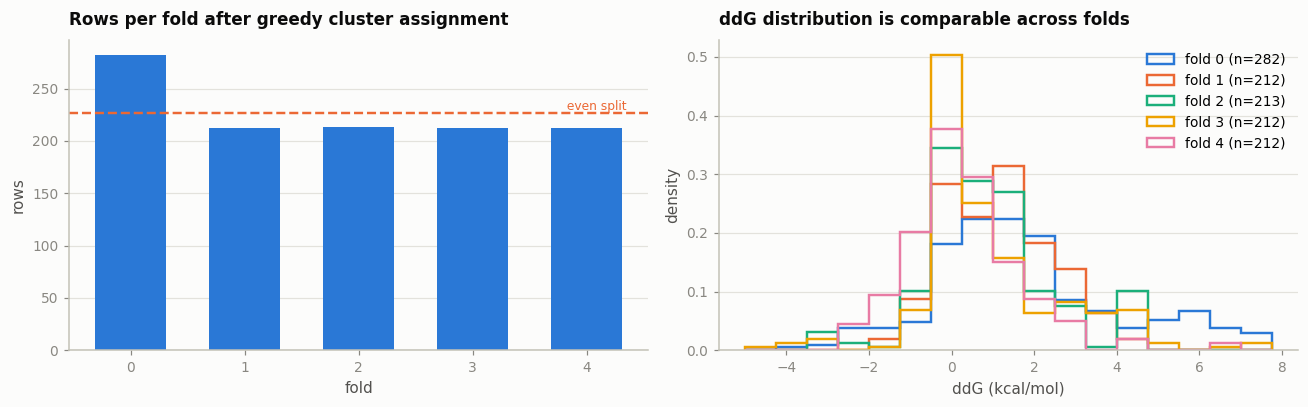

In [23]:
# greedy 5-fold assignment, balancing row count
K = 5
folds = {i: {"rows":0, "clusters":[]} for i in range(K)}
for c, r in cl["rows"].items():
    i = min(folds, key=lambda j: folds[j]["rows"])
    folds[i]["rows"] += r; folds[i]["clusters"].append(c)

fold_of = {c:i for i,f in folds.items() for c in f["clusters"]}
ab["fold"] = ab["cluster"].map(fold_of)
ft = ab.groupby("fold").agg(rows=("ddG","size"), complexes=("#Pdb","nunique"),
                            clusters=("cluster","nunique"), ddG_mean=("ddG","mean"),
                            ddG_sd=("ddG","std")).round(2)
ft["% of rows"] = (ft["rows"]/len(ab)*100).round(1)
print(ft.to_string())
print(f"\nrow-count imbalance: smallest fold {ft['rows'].min()}, largest {ft['rows'].max()}, "
      f"ratio {ft['rows'].max()/ft['rows'].min():.2f}x")

fig, axes = plt.subplots(1,2, figsize=(12,3.8))
ax = axes[0]
ax.bar(ft.index.astype(str), ft["rows"], color=C["blue"], width=.62)
ax.axhline(len(ab)/K, color=C["orange"], lw=1.6, ls="--")
ax.text(4.35, len(ab)/K, " even split", color=C["orange"], fontsize=8, va="bottom", ha="right")
style(ax, "Rows per fold after greedy cluster assignment", "fold", "rows")

ax = axes[1]
for i in range(K):
    v = ab.loc[ab.fold==i, "ddG"]
    ax.hist(v, bins=np.arange(-5,8.5,.75), histtype="step", lw=1.6,
            color=list(C.values())[i], label=f"fold {i} (n={len(v)})", density=True)
ax.legend(loc="upper right")
style(ax, "ddG distribution is comparable across folds", "ddG (kcal/mol)", "density")
plt.tight_layout(); plt.show()

In [24]:
# leakage sanity check: worst-case sequence identity between folds
worst=[]
for i in range(K):
    te = [k for k in keys if fold_of[find(k)]==i]
    tr = [k for k in keys if fold_of[find(k)]!=i]
    mx_ag = max((ident(AGS[a_],AGS[b_]) for a_ in te for b_ in tr), default=0)
    mx_ab = max((ident(ABS_[a_],ABS_[b_]) for a_ in te for b_ in tr), default=0)
    worst.append((i, len(te), round(mx_ag,2), round(mx_ab,2)))
lk = pd.DataFrame(worst, columns=["fold","test complexes","max antigen identity vs train",
                                  "max antibody identity vs train"])
print("Antibodies share framework, so high antibody identity is expected and is not by itself")
print("leakage; the antigen column is the one that must stay low.\n")
lk

Antibodies share framework, so high antibody identity is expected and is not by itself
leakage; the antigen column is the one that must stay low.



,fold,test complexes,max antigen identity vs train,max antibody identity vs train
0,0,13,0.22,0.84
1,1,5,0.42,0.89
2,2,12,0.69,0.89
3,3,11,0.55,0.88
4,4,13,0.69,0.88


## 9. What this changes

In [25]:
summary = pd.DataFrame([
    ("rows after label construction",        f"{len(ab):,}", "start of the usable set"),
    ("rows verifying against structure",     f"{ab.struct_ok.sum():,} ({ab.struct_ok.mean():.0%})",
     "upper bound on anything structure-featurised"),
    ("unique (complex, mutation)",           f"{ab.groupby(dup_key).ngroups:,}",
     "true sample size after deduplication"),
    ("complexes / clusters",                 f"{ab['#Pdb'].nunique()} / {ab['cluster'].nunique()}",
     "the unit of independence"),
    ("largest cluster share",                f"{cl['% of rows'].iloc[0]:.0f}%",
     "drives fold imbalance"),
    ("X->Ala share of single mutations",     f"{(sing.mut_aa=='A').mean():.0%}",
     "compositional bias to slice on"),
    ("max attainable per-complex r",
     f"{ceiling(sd_within, sd_noise_pap)[1]:.2f} conservative / {ceiling(sd_within, sd_noise_emp)[1]:.2f} optimistic",
     "ceiling for the headline metric"),
    ("balanced 5-fold split feasible?",
     f"no — largest cluster is {cl['% of rows'].iloc[0]:.0f}% of rows",
     "fold 0 is one cluster; consider 4 folds or leave-one-cluster-out"),
], columns=["quantity","value","why it matters"]).set_index("quantity")
summary

,value,why it matters
quantity,,
rows after label construction,"1,131",start of the usable set
rows verifying against structure,"1,131 (100%)",upper bound on anything structure-featurised
"unique (complex, mutation)",997,true sample size after deduplication
complexes / clusters,54 / 26,the unit of independence
largest cluster share,25%,drives fold imbalance
X->Ala share of single mutations,53%,compositional bias to slice on
max attainable per-complex r,0.91 conservative / 0.97 optimistic,ceiling for the headline metric
balanced 5-fold split feasible?,no — largest cluster is 25% of rows,fold 0 is one cluster; consider 4 folds or lea...


Findings and their consequences are written up in `EDA_FINDINGS.md`. The next build step is the
repo skeleton plus `evaluate.py` against a dummy mean predictor, then `src/splits.py` writing the
frozen `folds.csv` using MMseqs2 in place of the `difflib` stand-in above.